In [ ]:
pip install pandas scikit-learn matplotlib scipy shap kmodes

# TRATAMENTO DOS DADOS

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Ler o CSV
df = pd.read_csv("data.csv")

# 2. Colunas nominais para codificação
cols_to_encode = [
    "gender",
    "basicSchoolType",
    "schoolExactInterestByGender",
    "admiredExactTeachersGender"
]

# 3. Colunas ordinais e suas categorias
ordinal_categories = {
    "childhoodHobbiesTime": ["nao-raremente", "raramente-responsabilidades", "as-vezes", "sim-tempo-apoio"],
    "futureProfessionalSelf": [1,2,3,4,5],
    "stemCareerInterest": [1,2,3,4,5],
    "stemCareerEverInterest": ["nao","nao-tenho-certeza","sim"],
    "preCollegeExactInterestLevel": ["muito-interesse","algum-interesse","pouco-interesse","nenhum-interesse"],
    "familySchoolPerformanceValue": ["valorizava-muito","valorizava-moderadamente","valorizava-eventualmente","nao-demonstrava-interesse","nao-valorizava"],
    "teacherPerformanceValue": ["maioria-valorizava","alguns-valorizavam","tratavam-neutro","poucos-valorizavam","desempenho-ignorado"],
    "lostInterestExactSciences": ["sim-perdi","nao-perdi","nunca-tive-interesse"],
    "feltSTEMNotForMeEver": ["nao-nunca-senti","nunca-pensei", "sim-ja-senti"],
    "feelingExcludedTech": [1,2,3,4,5],
    "feelingExcludedExact": [1,2,3,4,5],
    "familyStudyIncentive": [1,2,3,4,5],
    "activityGenderRestriction": [1,2,3,4,5],
    "professionsByGenderOpinion": [1,2,3,4,5],}

# 4. Codificar variáveis ordinais
for col, categories in ordinal_categories.items():
    if col in df.columns:
        df[col] = pd.Categorical(df[col], categories=categories, ordered=True).codes
        df[col] = df[col].replace(-1, pd.NA)

# 5. Codificar variáveis nominais
for col in cols_to_encode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

# 6. Converter booleanos e garantir formato numérico
df = df.replace({True: 1, False: 0})
df = df.apply(pd.to_numeric, errors="coerce")

# 7. Aplicar Min-Max Scaling em TODAS as colunas numéricas
scaler = MinMaxScaler()
# 7. Aplicar Min-Max Scaling em todas as colunas numéricas EXCETO o target
num_cols = [c for c in df.columns if c != "gender"]
df[num_cols] = scaler.fit_transform(df[num_cols].astype(float))


# --- FILTRAR APENAS AS COLUNAS DESEJADAS ---
colunas_finais = list(cols_to_encode) + list(ordinal_categories.keys())
colunas_finais = [c for c in colunas_finais if c in df.columns]  # garante existência

df_final = df[colunas_finais]

# 8. Conferir valores únicos
print("\n📊 Valores únicos das colunas ordinais após codificação e normalização:")
for col in ordinal_categories.keys():
    if col in df.columns:
        print(f"{col}: {sorted(df[col].dropna().unique())}")

# 9. Salvar resultado final
df_final.to_csv("data_scaled_all_minmax_stem.csv", index=False)
print("\n💾 Arquivo final salvo como 'data_scaled_all_minmax_stem.csv'")



📊 Valores únicos das colunas ordinais após codificação e normalização:
childhoodHobbiesTime: [np.float64(0.0), np.float64(0.3333333333333333), np.float64(0.6666666666666666), np.float64(1.0)]
futureProfessionalSelf: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
stemCareerInterest: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
stemCareerEverInterest: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
preCollegeExactInterestLevel: [np.float64(0.0), np.float64(0.3333333333333333), np.float64(0.6666666666666666), np.float64(1.0)]
familySchoolPerformanceValue: [np.float64(0.0), np.float64(0.3333333333333333), np.float64(0.6666666666666666), np.float64(1.0)]
teacherPerformanceValue: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
lostInterestExactSciences: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
feltSTEMNotForMeEver: [np.float64(0.0), np.float64(0.5), np.f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Ler CSV
df = pd.read_csv("data.csv")
df_original = df.copy()  # cópia para valores originais

# 2. Colunas nominais
cols_to_encode = [
    "gender",
    "basicSchoolType",
    "schoolExactInterestByGender",
    "admiredExactTeachersGender"
]

# 3. Colunas ordinais
ordinal_categories = {
    "childhoodHobbiesTime": ["nao-raremente", "raramente-responsabilidades", "as-vezes", "sim-tempo-apoio"],
    "futureProfessionalSelf": [1,2,3,4,5],
    "stemCareerInterest": [1,2,3,4,5],
    "stemCareerEverInterest": ["nao","nao-tenho-certeza","sim"],
    "preCollegeExactInterestLevel": ["muito-interesse","algum-interesse","pouco-interesse","nenhum-interesse"],
    "familySchoolPerformanceValue": ["valorizava-muito","valorizava-moderadamente","valorizava-eventualmente","nao-demonstrava-interesse","nao-valorizava"],
    "teacherPerformanceValue": ["maioria-valorizava","alguns-valorizavam","tratavam-neutro","poucos-valorizavam","desempenho-ignorado"],
    "lostInterestExactSciences": ["sim-perdi","nao-perdi","nunca-tive-interesse"],
    "feltSTEMNotForMeEver": ["nao-nunca-senti","nunca-pensei", "sim-ja-senti"],
    "feelingExcludedTech": [1,2,3,4,5],
    "feelingExcludedExact": [1,2,3,4,5],
    "familyStudyIncentive": [1,2,3,4,5],
    "activityGenderRestriction": [1,2,3,4,5],
    "professionsByGenderOpinion": [1,2,3,4,5],
}

# 4. Codificar ordinais
df_encoded = df.copy()
for col, categories in ordinal_categories.items():
    if col in df_encoded.columns:
        df_encoded[col] = pd.Categorical(df_encoded[col], categories=categories, ordered=True).codes
        df_encoded[col] = df_encoded[col].replace(-1, pd.NA)

# 5. Codificar nominais
for col in cols_to_encode:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 6. Converter booleanos
df_encoded = df_encoded.replace({True:1, False:0})
df_encoded = df_encoded.apply(pd.to_numeric, errors="coerce")

# 7. Normalizar colunas numéricas
scaler = MinMaxScaler()
num_cols = [c for c in df_encoded.columns if c not in cols_to_encode]
df_normalized = df_encoded.copy()
df_normalized[num_cols] = scaler.fit_transform(df_normalized[num_cols].astype(float))

# --- Função para gerar tabela LaTeX ---
def latex_translation_table(var):
    if var not in df_original.columns:
        return ""
    original = pd.Series(sorted(df_original[var].dropna().unique()))
    codificado = pd.Series(sorted(df_encoded[var].dropna().unique()))
    if var in df_normalized.columns:
        normalizado = pd.Series([round(x,2) for x in sorted(df_normalized[var].dropna().unique())])
    else:
        normalizado = codificado
    # Montar LaTeX usando string raw (r"")
    latex = r"\begin{table}[H]" + "\n"
    latex += r"\centering" + "\n"
    latex += f"\\caption{{Tabela de tradução da variável {var}}}\n"
    latex += r"\begin{tabular}{p{6cm} p{3cm} p{3cm}}" + "\n"
    latex += r"\hline" + "\n"
    latex += r"\textbf{Valor Original} & \textbf{Codificado} & \textbf{Normalizado} \\" + "\n"
    latex += r"\hline" + "\n"
    for o, c, n in zip(original, codificado, normalizado):
        latex += f"\\raggedright {o} & {c} & {n:.2f} \\\\\n"
    latex += r"\hline" + "\n"
    latex += rf"\end{{tabular}}" + "\n"
    latex += rf"\label{{tab:traducao_{var}}}" + "\n"
    latex += rf"\end{{table}}" + "\n"
    return latex

# Exemplo de uso:
variaveis = [
    'feelingExcludedTech',
    'activityGenderRestriction',
    'professionsByGenderOpinion',
    'feltSTEMNotForMeEver',
    'stemCareerInterest',
    'admiredExactTeachersGender',
    'schoolExactInterestByGender',
    'familySchoolPerformanceValue',
    'feelingExcludedExact',
    'stemCareerEverInterest',
    'childhoodHobbiesTime',
    'familyStudyIncentive',
    'preCollegeExactInterestLevel',
    'teacherPerformanceValue',





]
for var in variaveis:
    print(latex_translation_table(var))



\begin{table}[H]
\centering
\caption{Tabela de tradução da variável feelingExcludedTech}
\begin{tabular}{p{6cm} p{3cm} p{3cm}}
\hline
\textbf{Valor Original} & \textbf{Codificado} & \textbf{Normalizado} \\
\hline
\raggedright 1 & 0 & 0.00 \\
\raggedright 2 & 1 & 0.33 \\
\raggedright 3 & 2 & 0.67 \\
\raggedright 4 & 3 & 1.00 \\
\hline
\end{tabular}
\label{tab:traducao_feelingExcludedTech}
\end{table}

\begin{table}[H]
\centering
\caption{Tabela de tradução da variável activityGenderRestriction}
\begin{tabular}{p{6cm} p{3cm} p{3cm}}
\hline
\textbf{Valor Original} & \textbf{Codificado} & \textbf{Normalizado} \\
\hline
\raggedright 1 & 0 & 0.00 \\
\raggedright 2 & 1 & 0.25 \\
\raggedright 3 & 2 & 0.50 \\
\raggedright 4 & 3 & 0.75 \\
\raggedright 5 & 4 & 1.00 \\
\hline
\end{tabular}
\label{tab:traducao_activityGenderRestriction}
\end{table}

\begin{table}[H]
\centering
\caption{Tabela de tradução da variável professionsByGenderOpinion}
\begin{tabular}{p{6cm} p{3cm} p{3cm}}
\hline
\textbf{Va

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


# SHAP AMBOS OS GENEROS, ALVO=GENDER

✅ Modelo Random Forest Regressor treinado com sucesso!

📊 Gerando gráfico de importância global...


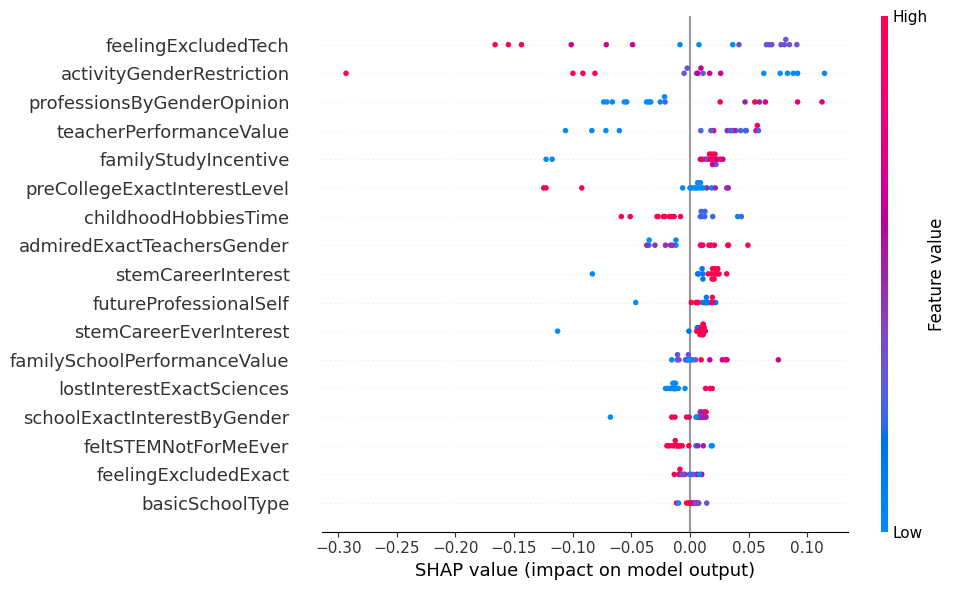


📊 Gerando gráfico de importância global (TOP 8)...

🏆 Top 10 variáveis mais influentes (média SHAP):
                         Feature  SHAP_importance
12           feelingExcludedTech         0.077742
15     activityGenderRestriction         0.064792
16    professionsByGenderOpinion         0.052785
9        teacherPerformanceValue         0.047644
14          familyStudyIncentive         0.029995
7   preCollegeExactInterestLevel         0.028852
3           childhoodHobbiesTime         0.023377
2     admiredExactTeachersGender         0.022901

🔎 Exemplo dos dados (8 variáveis mais importantes):
    feelingExcludedTech  activityGenderRestriction  \
76             0.000000                       1.00   
0              0.333333                       0.00   
26             0.333333                       0.50   
22             0.333333                       0.00   
12             0.000000                       0.00   
67             0.666667                       0.50   
10             1.

In [ ]:
# ==============================================
# 🔍 Interpretação de modelo com SHAP (Regressor)
# ==============================================

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# ===============================
# 1. Carregar dataset
# ===============================
df = pd.read_csv("data_scaled_all_minmax_stem.csv")

target = "gender"

# Remover registros sem target
df = df.dropna(subset=[target])

# Separar features e alvo
X = df.drop(columns=[target])
y = df[target].astype(float)

# ===============================
# 2. Divisão treino/teste
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 3. Treinar modelo
# ===============================
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

print("✅ Modelo Random Forest Regressor treinado com sucesso!")

# ===============================
# 4. Gerar valores SHAP
# ===============================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ===============================
# 5. Importância Global (SHAP summary)
# ===============================
print("\n📊 Gerando gráfico de importância global...")
shap.summary_plot(shap_values, X_test, plot_size=(10,6))

plt.show()

print("\n📊 Gerando gráfico de importância global (TOP 8)...")

# Garantir que importance_df já foi criado aqui
shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_importance": shap_importance
}).sort_values(by="SHAP_importance", ascending=False)

# 1. Top 8 features
top_features = importance_df["Feature"].head(8).tolist()

# 2. Índices reais das top 8
feature_indices = [X.columns.get_loc(f) for f in top_features]

# 3. Filtrar shap_values corretamente usando os índices
shap_values_top = shap_values[:, feature_indices]

# 4. Filtrar X_test também
X_test_top = X_test[top_features]

# Criar figura manual
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_top,
    X_test_top,
    feature_names=top_features,
    show=False,
    plot_size=(10, 6)
)

plt.savefig("shap_summary_top8_gender.png", dpi=300, bbox_inches="tight")
plt.close()


# ===============================
# 6. Ranking Numérico de Importância
# ===============================
# Média absoluta dos valores SHAP por feature
shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_importance": shap_importance
}).sort_values(by="SHAP_importance", ascending=False)

print("\n🏆 Top 10 variáveis mais influentes (média SHAP):")
print(importance_df.head(8))

# ===============================
# 6.1. Exemplo dos dados das 8 variáveis mais importantes
# ===============================
top_features = importance_df["Feature"].head(8).tolist()

print("\n🔎 Exemplo dos dados (8 variáveis mais importantes):")
print(X_test[top_features].head(8))  # mostra as 10 primeiras amostras do teste

# ===============================
# 7. Explicação Individual (opcional)
# ===============================
print("\n🔍 Exemplo de explicação individual (1ª amostra de teste):")
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
)


# USANDO O CLASSIFIER, COM ALVO GENDER E CLASSIFICAÇÃO PARA PREVER GENERO FEMININNO


================ CHECKS INICIAIS ================

SHAPE DO DF: (88, 18)
COLUNAS: ['gender', 'basicSchoolType', 'schoolExactInterestByGender', 'admiredExactTeachersGender', 'childhoodHobbiesTime', 'futureProfessionalSelf', 'stemCareerInterest', 'stemCareerEverInterest', 'preCollegeExactInterestLevel', 'familySchoolPerformanceValue', 'teacherPerformanceValue', 'lostInterestExactSciences', 'feltSTEMNotForMeEver', 'feelingExcludedTech', 'feelingExcludedExact', 'familyStudyIncentive', 'activityGenderRestriction', 'professionsByGenderOpinion']

SHAPE DE X: (88, 17)
SHAPE DE y: (88,)

SHAPES:
X_train: (70, 17)
X_test: (18, 17)

Modelo treinado com sucesso!

Iniciando SHAP com shap.Explainer...

SHAP calculado!
Tipo: <class 'shap._explanation.Explanation'>
shap_values.values.shape: (18, 17, 2)
shap_values_class1.shape: (18, 17)

Gerando summary plot...


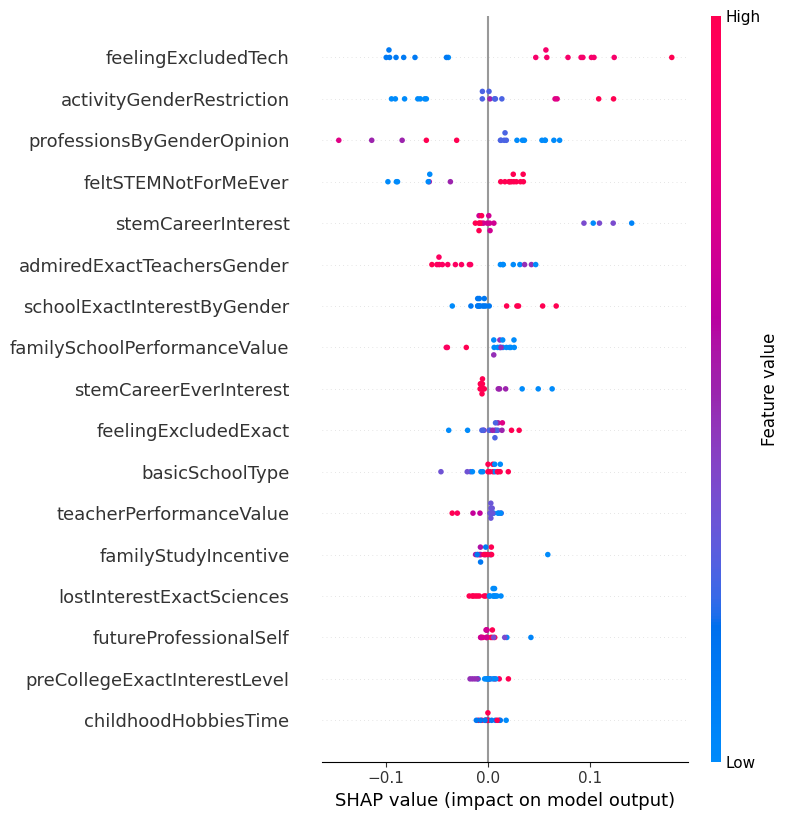


Gerando bar plot...


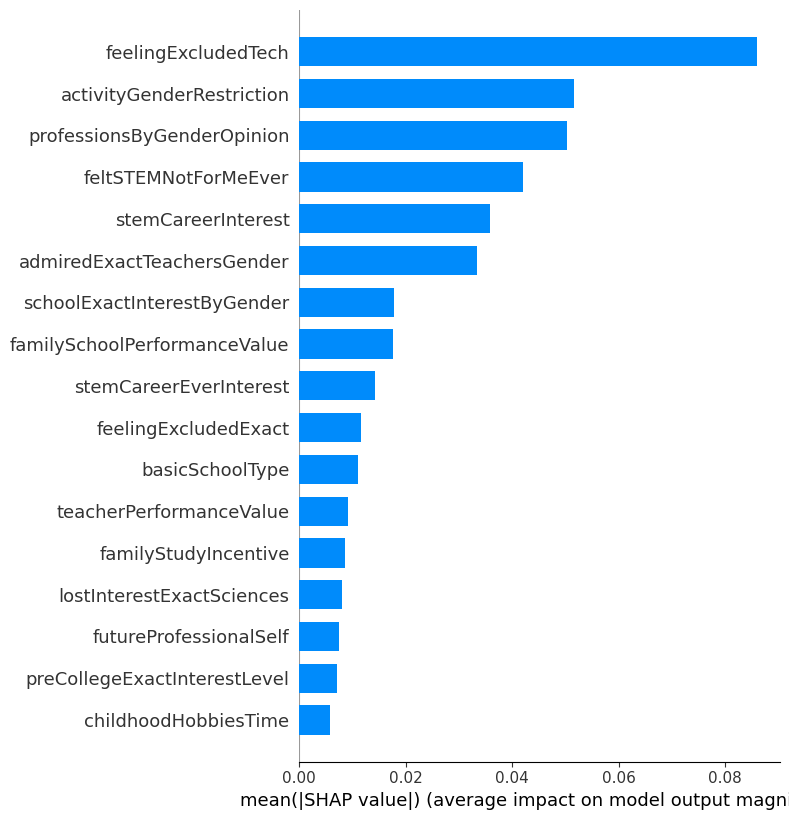


Gerando dependence plot da feature mais importante...
Feature mais importante: feelingExcludedTech


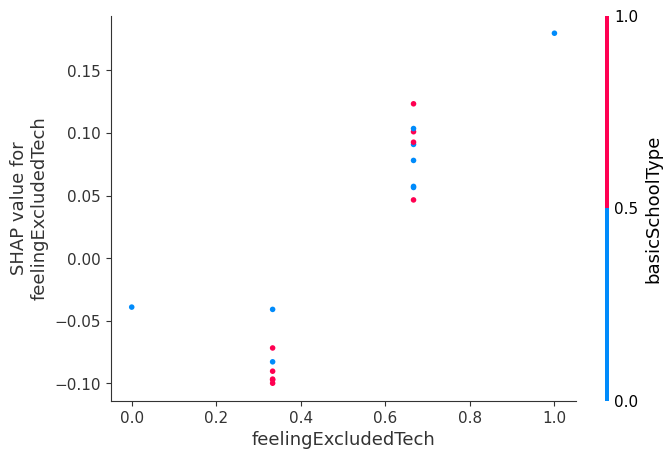

✅ SHAP summary plot dos top 8 features salvo como 'shap_summary_top8_gender.png'


In [ ]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ======================================================

# 1. Carregar os Dados

# ======================================================

df = pd.read_csv("data_scaled_all_minmax_stem.csv")

print("\n================ CHECKS INICIAIS ================\n")
print("SHAPE DO DF:", df.shape)
print("COLUNAS:", df.columns.tolist())

# ======================================================

# 2. Separar X e y

# ======================================================

X = df.drop(columns=["gender"])
y = df["gender"]

print("\nSHAPE DE X:", X.shape)
print("SHAPE DE y:", y.shape)

# ======================================================

# 3. Divisão Treino/Teste

# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nSHAPES:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# ======================================================

# 4. Treinamento do Modelo

# ======================================================

model = RandomForestClassifier(
n_estimators=300,
random_state=42,
n_jobs=-1,
class_weight="balanced"
)

model.fit(X_train, y_train)
print("\nModelo treinado com sucesso!")

# ======================================================

# 5. SHAP — Explainer da nova API

# ======================================================

print("\nIniciando SHAP com shap.Explainer...")

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

print("\nSHAP calculado!")
print("Tipo:", type(shap_values))
print("shap_values.values.shape:", shap_values.values.shape)  # (n_samples, n_features, n_classes)

# ======================================================

# 6. Selecionar classe 1 (feminino)

# ======================================================

shap_values_class1 = shap_values.values[:, :, 0]  # shape (n_samples, n_features)
print("shap_values_class1.shape:", shap_values_class1.shape)

# ======================================================

# 7. Summary Plot

# ======================================================

print("\nGerando summary plot...")
shap.summary_plot(shap_values_class1, X_test)

# ======================================================

# 8. Bar Plot (importância média)

# ======================================================

print("\nGerando bar plot...")
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# ======================================================

# 9. Dependence Plot da feature mais importante

# ======================================================

print("\nGerando dependence plot da feature mais importante...")

importances = np.mean(np.abs(shap_values_class1), axis=0)
top_feature = X.columns[np.argmax(importances)]
print("Feature mais importante:", top_feature)

shap.dependence_plot(top_feature, shap_values_class1, X_test)


# ======================================================

# Gerar e salvar o summary plot dos top 8 features

# ======================================================

# Calcular importância média das features

shap_importance = np.abs(shap_values_class1).mean(axis=0)
importance_df = pd.DataFrame({
"Feature": X.columns,
"SHAP_importance": shap_importance
}).sort_values(by="SHAP_importance", ascending=False)

# Selecionar top 8 features

top_features = importance_df["Feature"].head(8).tolist()
feature_indices = [X.columns.get_loc(f) for f in top_features]

# Filtrar shap_values e X_test para as top 8

shap_values_top8 = shap_values_class1[:, feature_indices]
X_test_top8 = X_test[top_features]

# Criar e salvar o gráfico

plt.figure(figsize=(10, 6))
shap.summary_plot(
shap_values_top8,
X_test_top8,
feature_names=top_features,
show=False,
plot_size=(10, 6)
)
plt.savefig("shap_summary_top8_gender.png", dpi=300, bbox_inches="tight")
plt.close()

print("✅ SHAP summary plot dos top 8 features salvo como 'shap_summary_top8_gender.png'")


In [ ]:
X.columns
X.shape
df.shape
df.head()
df_final.columns
df_final.shape


(88, 19)

# REDE HIERARQUICA

✅ Dados carregados com sucesso!

🧬 Gerando o dendrograma...


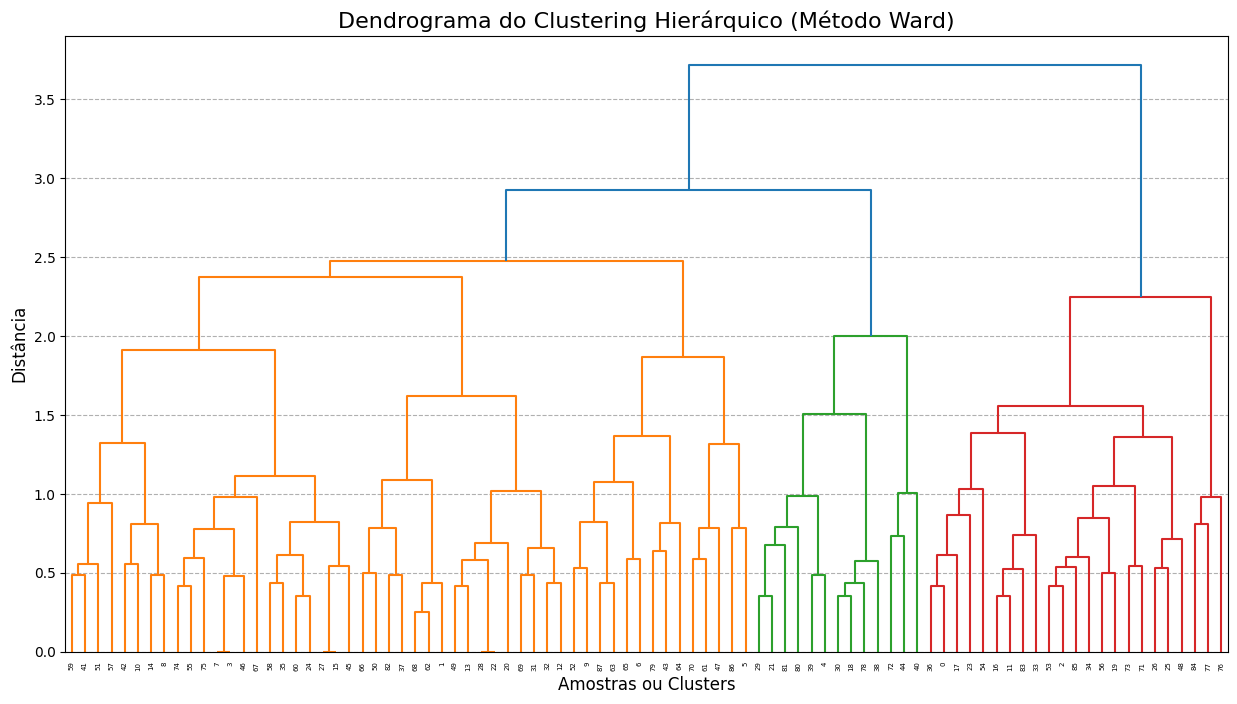


🔍 Avaliando número ideal de clusters (método do cotovelo e silhueta)...


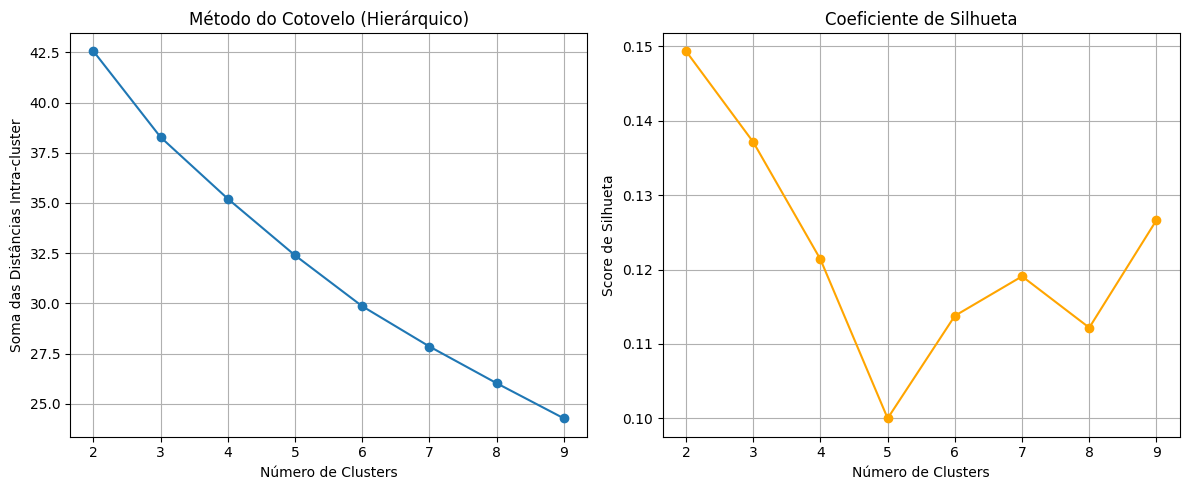


📉 Número ideal de clusters (pelo método do cotovelo): 2
📈 Melhor Silhouette Score: 0.149 (para 2 clusters)

🔎 Análise para 2 clusters:

----- Análise da Feature: 'feelingExcludedTech' -----
feelingExcludedTech  0.000000  0.333333  0.666667  1.000000
cluster_id                                                 
1                           7         9         7         0
2                           5        28        22        10


----- Análise da Feature: 'activityGenderRestriction' -----
activityGenderRestriction  0.00  0.25  0.50  0.75  1.00
cluster_id                                             
1                            10     5     4     1     3
2                            12    30    11    10     2


----- Análise da Feature: 'professionsByGenderOpinion' -----
professionsByGenderOpinion  0.00  0.25  0.50  0.75  1.00
cluster_id                                              
1                              0     1     8    11     3
2                             43    18     2     

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ======================================================
# 1. Carregar os Dados
# ======================================================
try:
    df = pd.read_csv('data_scaled_all_minmax_stem.csv')
    print("✅ Dados carregados com sucesso!")
except FileNotFoundError:
    print("⚠️  O arquivo 'data_encoded.csv' não foi encontrado. Criando dados de exemplo...")


# ======================================================
# 2. Selecionar as Features Mais Importantes
# ======================================================
features_importantes = [
    'feelingExcludedTech',
    'activityGenderRestriction',
    'professionsByGenderOpinion',
    'teacherPerformanceValue',
    'preCollegeExactInterestLevel',
    'familyStudyIncentive',
    'stemCareerInterest',
    'childhoodHobbiesTime'
]


# Se algumas colunas não existirem (no dataset de exemplo), ignorar
df_features = df[[col for col in features_importantes if col in df.columns]].copy()

# ======================================================
# 4. Aplicar Clustering Hierárquico, ADIÇÃO DE PCA PARA MELHORIA DOS CLUSTERS
# ======================================================
matriz_de_ligacao = linkage(df_features, method='ward')

# ======================================================
# 5. Visualizar Dendrograma
# ======================================================
plt.figure(figsize=(15, 8))
print("\n🧬 Gerando o dendrograma...")
dendrogram(
    matriz_de_ligacao,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrograma do Clustering Hierárquico (Método Ward)', fontsize=16)
plt.xlabel('Amostras ou Clusters', fontsize=12)
plt.ylabel('Distância', fontsize=12)
plt.grid(axis='y', linestyle='--')

plt.show()

# ======================================================
# 6. Determinar Número Ideal de Clusters (Cotovelo + Silhueta)
# ======================================================
range_n_clusters = range(2, 10)
silhouette_scores = []
within_cluster_variance = []

# Pré-calcular distâncias
distances = pdist(df_pca, metric='euclidean')


print("\n🔍 Avaliando número ideal de clusters (método do cotovelo e silhueta)...")
for n_clusters in range_n_clusters:
    cluster_labels = fcluster(matriz_de_ligacao, t=n_clusters, criterion='maxclust')

    # Silhouette Score
    silhouette_avg = silhouette_score(df_pca, cluster_labels)

    silhouette_scores.append(silhouette_avg)

    # Variância intra-cluster (proxy do cotovelo)
    cluster_variance = 0
    for cluster_id in np.unique(cluster_labels):
        cluster_points = df_features[cluster_labels == cluster_id]
        cluster_center = cluster_points.mean(axis=0)
        cluster_variance += ((cluster_points - cluster_center) ** 2).sum().sum()
    within_cluster_variance.append(cluster_variance)

# ======================================================
# 7. Visualizar o Método do Cotovelo e Silhueta
# ======================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, within_cluster_variance, marker='o')
plt.title('Método do Cotovelo (Hierárquico)')
plt.xlabel('Número de Clusters')
plt.ylabel('Soma das Distâncias Intra-cluster')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', color='orange')
plt.title('Coeficiente de Silhueta')
plt.xlabel('Número de Clusters')
plt.ylabel('Score de Silhueta')
plt.grid(True)

plt.tight_layout()

plt.show()

# Determinar melhor número de clusters
melhor_n_clusters = range_n_clusters[np.argmin(np.gradient(within_cluster_variance))]
print(f"\n📉 Número ideal de clusters (pelo método do cotovelo): {melhor_n_clusters}")
print(f"📈 Melhor Silhouette Score: {max(silhouette_scores):.3f} (para {range_n_clusters[np.argmax(silhouette_scores)]} clusters)")

# ======================================================
# 8. Atribuir Amostras aos Clusters
# ======================================================
clusters = fcluster(matriz_de_ligacao, t=melhor_n_clusters, criterion='maxclust')
df['cluster_id'] = clusters

# ======================================================
# 9. Análise e Perfil dos Clusters
# ======================================================
print(f"\n🔎 Análise para {df['cluster_id'].nunique()} clusters:\n")

for feature in df_features.columns:
    print(f"----- Análise da Feature: '{feature}' -----")
    print(pd.crosstab(df['cluster_id'], df[feature]))
    print("\n")

print("----- Tamanho de cada Cluster -----")
print(df['cluster_id'].value_counts())


if 'gender' in df.columns:
    print("\n----- Contagem de Gênero por Cluster -----")
    print(pd.crosstab(df['cluster_id'], df['gender']))
else:
    print("\n⚠️  Coluna de gênero não encontrada no DataFrame.")


# REDE HIERARQUICA USANDO O SHAP COM CLASSIFIER

✅ Dados carregados com sucesso!

🧬 Gerando o dendrograma...


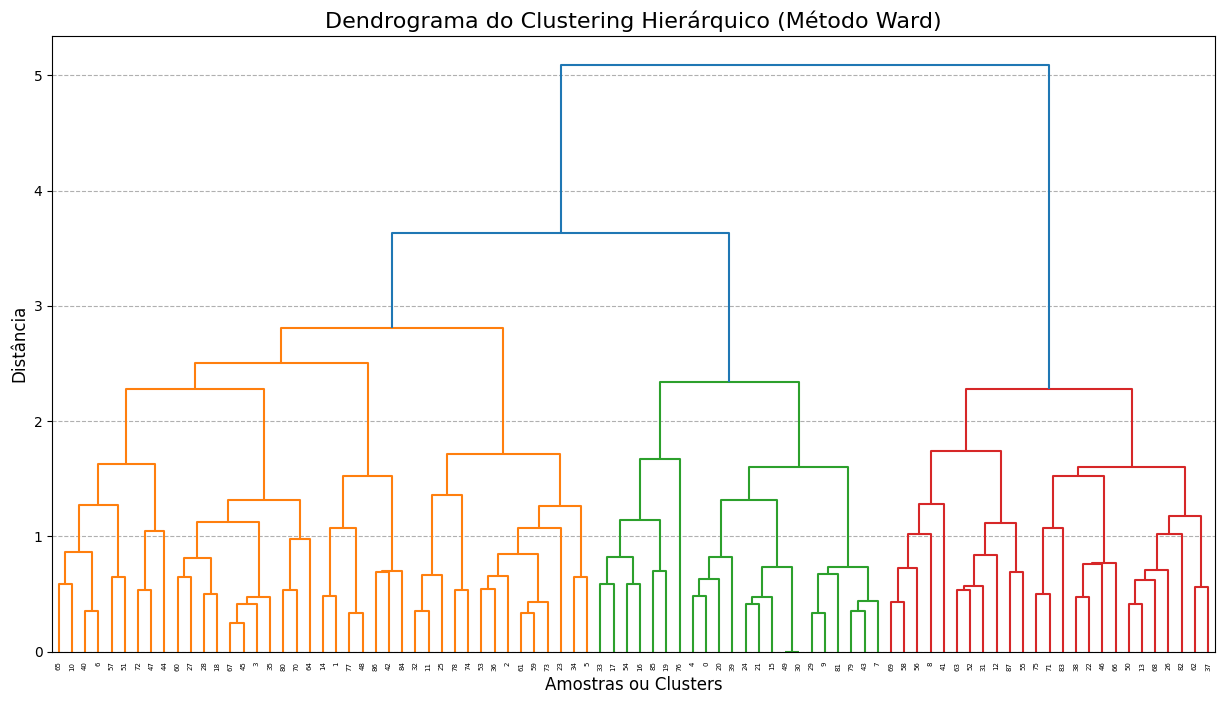


🔍 Avaliando número ideal de clusters (método do cotovelo e silhueta)...


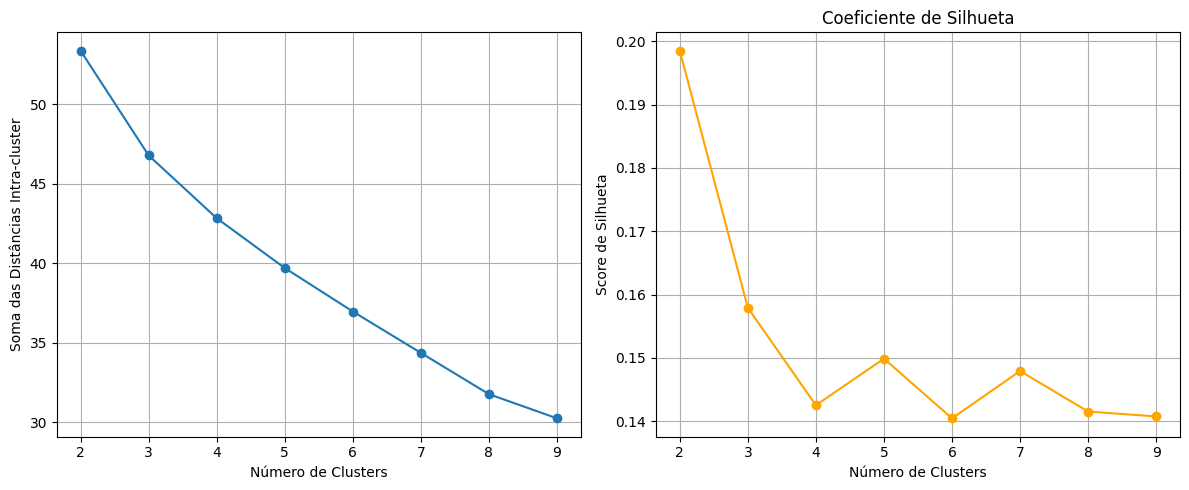

✅ Gráfico do método do cotovelo salvo como 'cotovelo_clusters.png'

📉 Número ideal de clusters (pelo método do cotovelo): 2
📈 Melhor Silhouette Score: 0.198 (para 2 clusters)

🔎 Análise para 2 clusters:

----- Análise da Feature: 'feelingExcludedTech' -----
feelingExcludedTech  0.000000  0.333333  0.666667  1.000000
cluster_id                                                 
1                           3        13         8         1
2                           9        24        21         9


----- Análise da Feature: 'activityGenderRestriction' -----
activityGenderRestriction  0.00  0.25  0.50  0.75  1.00
cluster_id                                             
1                             8     8     5     3     1
2                            14    27    10     8     4


----- Análise da Feature: 'professionsByGenderOpinion' -----
professionsByGenderOpinion  0.00  0.25  0.50  0.75  1.00
cluster_id                                              
1                             16     5 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ======================================================
# 1. Carregar os Dados
# ======================================================
try:
    df = pd.read_csv('data_scaled_all_minmax_stem.csv')
    print("✅ Dados carregados com sucesso!")
except FileNotFoundError:
    print("⚠️  O arquivo 'data_encoded.csv' não foi encontrado. Criando dados de exemplo...")


# ======================================================
# 2. Selecionar as Features Mais Importantes
# ======================================================
features_importantes = [
    'feelingExcludedTech',
    'activityGenderRestriction',
    'professionsByGenderOpinion',
    'feltSTEMNotForMeEver',
    'stemCareerInterest',
    'admiredExactTeachersGender',
    'schoolExactInterestByGender',
    'familySchoolPerformanceValue'
]


# Se algumas colunas não existirem (no dataset de exemplo), ignorar
df_features = df[[col for col in features_importantes if col in df.columns]].copy()

# ======================================================
# 4. Aplicar Clustering Hierárquico, ADIÇÃO DE PCA PARA MELHORIA DOS CLUSTERS
# ======================================================
matriz_de_ligacao = linkage(df_features, method='ward')

# ======================================================
# 5. Visualizar Dendrograma
# ======================================================
plt.figure(figsize=(15, 8))
print("\n🧬 Gerando o dendrograma...")
dendrogram(
    matriz_de_ligacao,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrograma do Clustering Hierárquico (Método Ward)', fontsize=16)
plt.xlabel('Amostras ou Clusters', fontsize=12)
plt.ylabel('Distância', fontsize=12)
plt.grid(axis='y', linestyle='--')

plt.show()

# ======================================================
# 6. Determinar Número Ideal de Clusters (Cotovelo + Silhueta)
# ======================================================
range_n_clusters = range(2, 10)
silhouette_scores = []
within_cluster_variance = []

# Pré-calcular distâncias
distances = pdist(df_features, metric='euclidean')


print("\n🔍 Avaliando número ideal de clusters (método do cotovelo e silhueta)...")
for n_clusters in range_n_clusters:
    cluster_labels = fcluster(matriz_de_ligacao, t=n_clusters, criterion='maxclust')

    # Silhouette Score
    silhouette_avg = silhouette_score(df_features, cluster_labels)

    silhouette_scores.append(silhouette_avg)

    # Variância intra-cluster (proxy do cotovelo)
    cluster_variance = 0
    for cluster_id in np.unique(cluster_labels):
        cluster_points = df_features[cluster_labels == cluster_id]
        cluster_center = cluster_points.mean(axis=0)
        cluster_variance += ((cluster_points - cluster_center) ** 2).sum().sum()
    within_cluster_variance.append(cluster_variance)

# ======================================================
# 7. Visualizar o Método do Cotovelo e Silhueta
# ======================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, within_cluster_variance, marker='o')

plt.xlabel('Número de Clusters')
plt.ylabel('Soma das Distâncias Intra-cluster')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', color='orange')
plt.title('Coeficiente de Silhueta')
plt.xlabel('Número de Clusters')
plt.ylabel('Score de Silhueta')
plt.grid(True)

plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, within_cluster_variance, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Soma das Distâncias Intra-cluster')
plt.title('Método do Cotovelo')
plt.grid(True)

plt.savefig("cotovelo_clusters.png", dpi=300, bbox_inches="tight")
plt.close()
print("✅ Gráfico do método do cotovelo salvo como 'cotovelo_clusters.png'")

# Determinar melhor número de clusters
melhor_n_clusters = range_n_clusters[np.argmin(np.gradient(within_cluster_variance))]
print(f"\n📉 Número ideal de clusters (pelo método do cotovelo): {melhor_n_clusters}")
print(f"📈 Melhor Silhouette Score: {max(silhouette_scores):.3f} (para {range_n_clusters[np.argmax(silhouette_scores)]} clusters)")

# ======================================================
# 8. Atribuir Amostras aos Clusters
# ======================================================
clusters = fcluster(matriz_de_ligacao, t=melhor_n_clusters, criterion='maxclust')
df['cluster_id'] = clusters

# ======================================================
# 9. Análise e Perfil dos Clusters
# ======================================================
print(f"\n🔎 Análise para {df['cluster_id'].nunique()} clusters:\n")

for feature in df_features.columns:
    print(f"----- Análise da Feature: '{feature}' -----")
    print(pd.crosstab(df['cluster_id'], df[feature]))
    print("\n")

print("----- Tamanho de cada Cluster -----")
print(df['cluster_id'].value_counts())


if 'gender' in df.columns:
    print("\n----- Contagem de Gênero por Cluster -----")
    print(pd.crosstab(df['cluster_id'], df['gender']))
else:
    print("\n⚠️  Coluna de gênero não encontrada no DataFrame.")


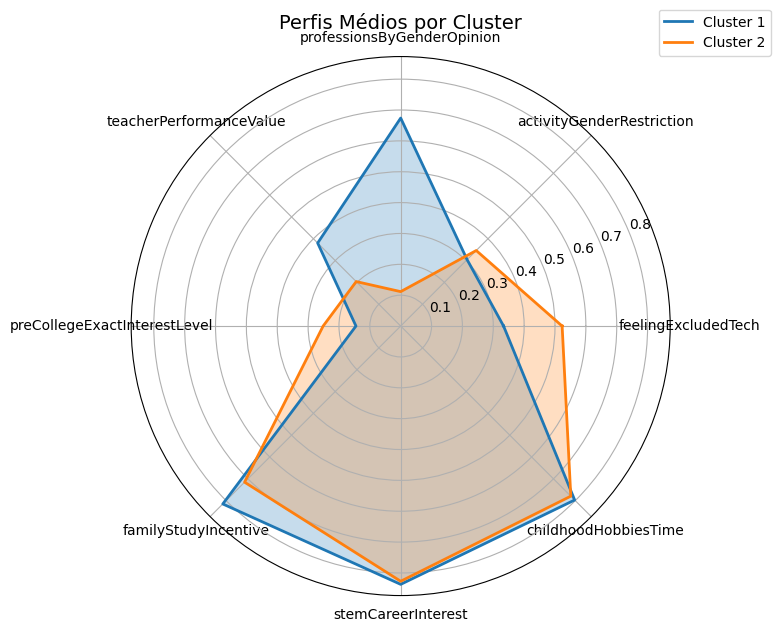

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Selecionar apenas as features de interesse (já numéricas)
cols = [
    'feelingExcludedTech',
    'activityGenderRestriction',
    'professionsByGenderOpinion',
    'teacherPerformanceValue',
    'preCollegeExactInterestLevel',
    'familyStudyIncentive',
    'stemCareerInterest',
    'childhoodHobbiesTime'
]

# Calcular médias por cluster
cluster_means = df.groupby('cluster_id')[cols].mean()

# Preparar o gráfico radar
labels = np.array(cols)
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (cluster, row) in enumerate(cluster_means.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {cluster}', linewidth=2)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_title("Perfis Médios por Cluster", fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.savefig("aranha_geral_gender_stem.png", dpi=300, bbox_inches="tight")
plt.show()


# GRAFICO DO CLASSIFIER

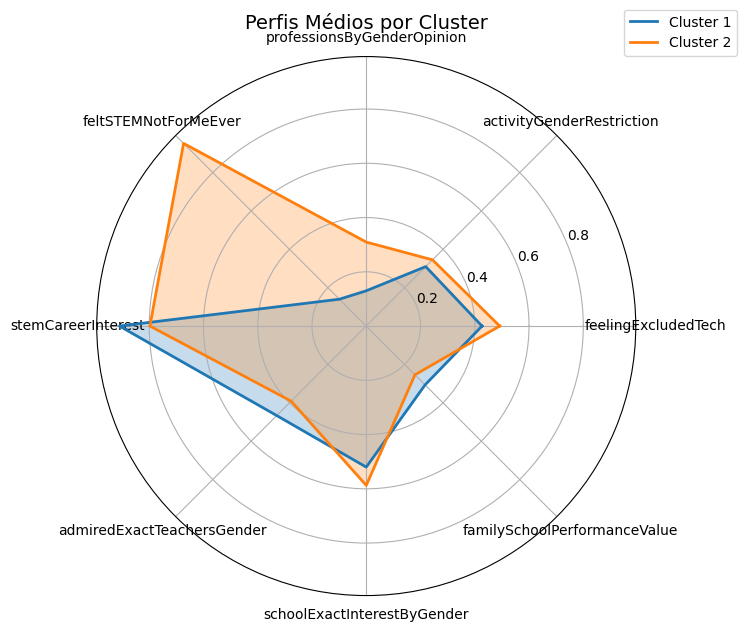

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Selecionar apenas as features de interesse (já numéricas)
cols =[
    'feelingExcludedTech',
    'activityGenderRestriction',
    'professionsByGenderOpinion',
    'feltSTEMNotForMeEver',
    'stemCareerInterest',
    'admiredExactTeachersGender',
    'schoolExactInterestByGender',
    'familySchoolPerformanceValue',
]


# Calcular médias por cluster
cluster_means = df.groupby('cluster_id')[cols].mean()

# Preparar o gráfico radar
labels = np.array(cols)
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (cluster, row) in enumerate(cluster_means.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {cluster}', linewidth=2)
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_title("Perfis Médios por Cluster", fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.savefig("aranha_geral_gender_stem.png", dpi=300, bbox_inches="tight")
plt.show()


# SHAP APENAS COM GENERO FEMININO, ALVO futureProfessionalSelf

✅ Modelo Random Forest Regressor treinado com sucesso!

📊 Gerando gráfico de importância global...


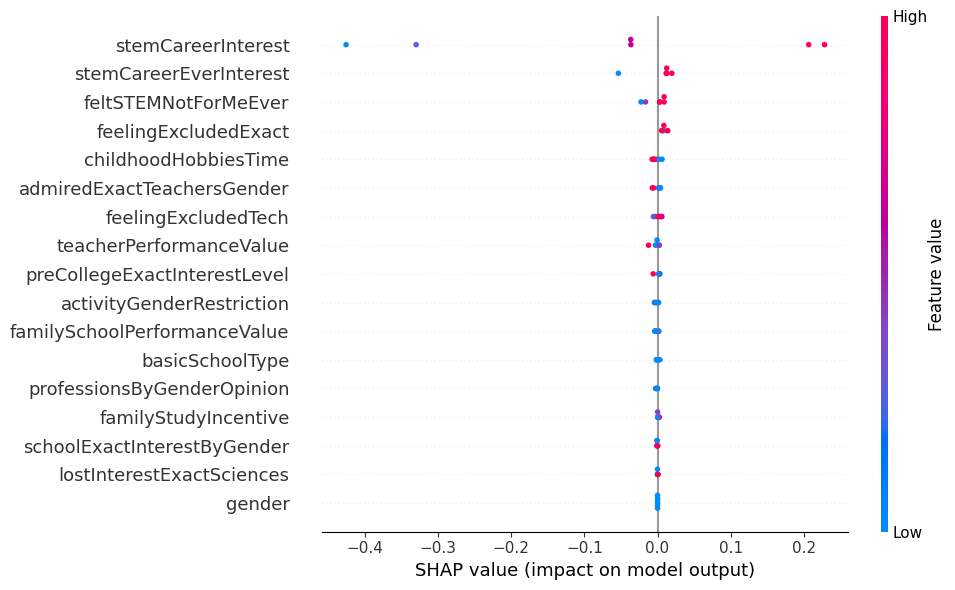

<Figure size 640x480 with 0 Axes>


📊 Gerando gráfico de importância global (TOP 8)...
📁 Imagem salva como 'shap_summary_top8_gender.png'

🏆 Top 10 variáveis mais influentes (média SHAP):
                         Feature  SHAP_importance
5             stemCareerInterest         0.210625
6         stemCareerEverInterest         0.020402
11          feltSTEMNotForMeEver         0.010525
13          feelingExcludedExact         0.009585
4           childhoodHobbiesTime         0.004810
3     admiredExactTeachersGender         0.004037
12           feelingExcludedTech         0.003852
9        teacherPerformanceValue         0.003493
7   preCollegeExactInterestLevel         0.002929
15     activityGenderRestriction         0.002505
8   familySchoolPerformanceValue         0.002499
1                basicSchoolType         0.001296
16    professionsByGenderOpinion         0.001033
14          familyStudyIncentive         0.000830
2    schoolExactInterestByGender         0.000544

🔎 Exemplo dos dados (8 variáveis mais importan

In [ ]:
# ==============================================
# 🔍 Interpretação de modelo com SHAP (Regressor)
# ==============================================

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# ===============================
# 1. Carregar dataset
# ===============================
df = pd.read_csv("data_scaled_all_minmax_stem.csv")
df = df[df['gender'] == 0.0].copy()

target = "futureProfessionalSelf"

# Remover registros sem target
df = df.dropna(subset=[target])

# Separar features e alvo
X = df.drop(columns=[target])
y = df[target].astype(float)

# ===============================
# 2. Divisão treino/teste
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 3. Treinar modelo
# ===============================
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

print("✅ Modelo Random Forest Regressor treinado com sucesso!")

# ===============================
# 4. Gerar valores SHAP
# ===============================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ===============================
# 5. Importância Global (SHAP summary)
# ===============================
print("\n📊 Gerando gráfico de importância global...")
shap.summary_plot(shap_values, X_test, plot_size=(10,6))

plt.savefig("cotovelo_geral_gender_stem.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n📊 Gerando gráfico de importância global (TOP 8)...")

# Garantir que importance_df já foi criado aqui
shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_importance": shap_importance
}).sort_values(by="SHAP_importance", ascending=False)

# 1. Top 8 features
top_features = importance_df["Feature"].head(8).tolist()

# 2. Índices reais das top 8
feature_indices = [X.columns.get_loc(f) for f in top_features]

# 3. Filtrar shap_values corretamente usando os índices
shap_values_top = shap_values[:, feature_indices]

# 4. Filtrar X_test também
X_test_top = X_test[top_features]

# Criar figura manual
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_top,
    X_test_top,
    feature_names=top_features,
    show=False,
    plot_size=(10, 6)
)

plt.savefig("shap_feminino_future_stem.png", dpi=300, bbox_inches="tight")
plt.close()

print("📁 Imagem salva como 'shap_summary_top8_gender.png'")

# ===============================
# 6. Ranking Numérico de Importância
# ===============================
# Média absoluta dos valores SHAP por feature
shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_importance": shap_importance
}).sort_values(by="SHAP_importance", ascending=False)

print("\n🏆 Top 10 variáveis mais influentes (média SHAP):")
print(importance_df.head(15))

# ===============================
# 6.1. Exemplo dos dados das 8 variáveis mais importantes
# ===============================
top_features = importance_df["Feature"].head(8).tolist()

print("\n🔎 Exemplo dos dados (8 variáveis mais importantes):")
print(X_test[top_features].head(15))  # mostra as 10 primeiras amostras do teste

# ===============================
# 7. Explicação Individual (opcional)
# ===============================
print("\n🔍 Exemplo de explicação individual (1ª amostra de teste):")
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
)


# SHAP APENAS COM GENERO MASCULINO, ALVO futureProfessionalSelf

✅ Modelo Random Forest Regressor treinado com sucesso!

📊 Gerando gráfico de importância global...


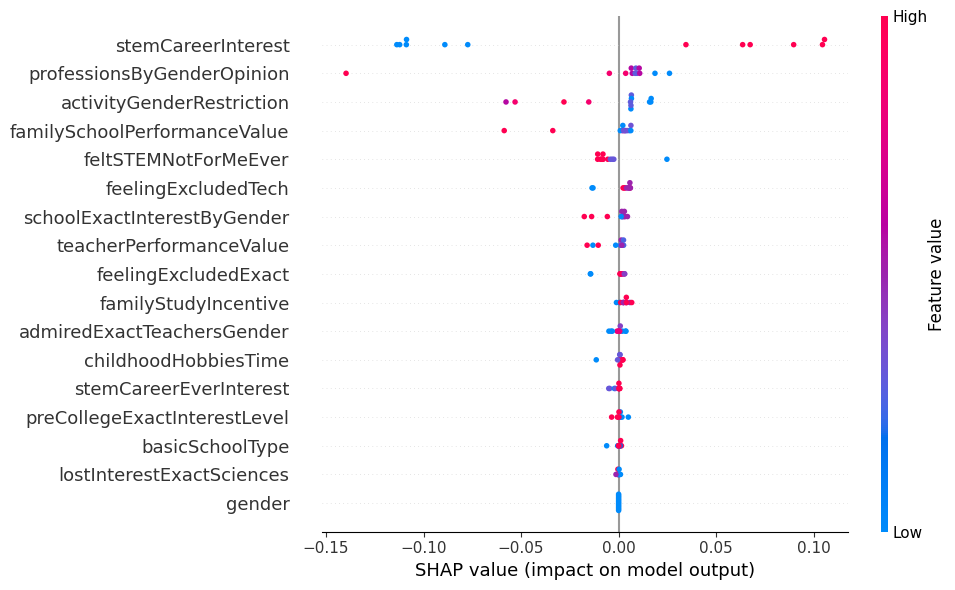


📊 Gerando gráfico de importância global (TOP 8)...
📁 Imagem salva como 'shap_summary_top8_gender.png'

🏆 Top 10 variáveis mais influentes (média SHAP):
                         Feature  SHAP_importance
5             stemCareerInterest         0.089603
16    professionsByGenderOpinion         0.021196
15     activityGenderRestriction         0.019582
8   familySchoolPerformanceValue         0.010754
11          feltSTEMNotForMeEver         0.008682
12           feelingExcludedTech         0.006050
2    schoolExactInterestByGender         0.004973
9        teacherPerformanceValue         0.004591
13          feelingExcludedExact         0.003811
14          familyStudyIncentive         0.003177
3     admiredExactTeachersGender         0.002063
4           childhoodHobbiesTime         0.002030
6         stemCareerEverInterest         0.001320
7   preCollegeExactInterestLevel         0.001223
1                basicSchoolType         0.001020

🔎 Exemplo dos dados (8 variáveis mais importan

In [ ]:
# ==============================================
# 🔍 Interpretação de modelo com SHAP (Regressor)
# ==============================================

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# ===============================
# 1. Carregar dataset
# ===============================
df = pd.read_csv("data_scaled_all_minmax_stem.csv")
df = df[df['gender'] == 1.0].copy()

target = "futureProfessionalSelf"

# Remover registros sem target
df = df.dropna(subset=[target])

# Separar features e alvo
X = df.drop(columns=[target])
y = df[target].astype(float)

# ===============================
# 2. Divisão treino/teste
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 3. Treinar modelo
# ===============================
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

print("✅ Modelo Random Forest Regressor treinado com sucesso!")

# ===============================
# 4. Gerar valores SHAP
# ===============================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ===============================
# 5. Importância Global (SHAP summary)
# ===============================
print("\n📊 Gerando gráfico de importância global...")
shap.summary_plot(shap_values, X_test, plot_size=(10,6))
plt.show()

print("\n📊 Gerando gráfico de importância global (TOP 8)...")

# Garantir que importance_df já foi criado aqui
shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_importance": shap_importance
}).sort_values(by="SHAP_importance", ascending=False)

# 1. Top 8 features
top_features = importance_df["Feature"].head(8).tolist()

# 2. Índices reais das top 8
feature_indices = [X.columns.get_loc(f) for f in top_features]

# 3. Filtrar shap_values corretamente usando os índices
shap_values_top = shap_values[:, feature_indices]

# 4. Filtrar X_test também
X_test_top = X_test[top_features]

# Criar figura manual
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_top,
    X_test_top,
    feature_names=top_features,
    show=False,
    plot_size=(10, 6)
)

plt.savefig("shap_masculino_future_stem.png", dpi=300, bbox_inches="tight")
plt.close()

print("📁 Imagem salva como 'shap_summary_top8_gender.png'")


# ===============================
# 6. Ranking Numérico de Importância
# ===============================
# Média absoluta dos valores SHAP por feature
shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_importance": shap_importance
}).sort_values(by="SHAP_importance", ascending=False)

print("\n🏆 Top 10 variáveis mais influentes (média SHAP):")
print(importance_df.head(15))

# ===============================
# 6.1. Exemplo dos dados das 8 variáveis mais importantes
# ===============================
top_features = importance_df["Feature"].head(8).tolist()

print("\n🔎 Exemplo dos dados (8 variáveis mais importantes):")
print(X_test[top_features].head(15))  # mostra as 10 primeiras amostras do teste

# ===============================
# 7. Explicação Individual (opcional)
# ===============================
print("\n🔍 Exemplo de explicação individual (1ª amostra de teste):")
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
)
